In [27]:
import pydicom
from pydicom.dataset import Dataset, FileDataset
from pydicom.uid import generate_uid
import os
import matplotlib.pylab as plt
import numpy as np
#import cv2
from skimage import exposure

21
../../../RadiomiK/Immagini/RADIOMIK_TO/RAD_TO/RAD_TO_LUNG_4_FBP_1.dcm
['../../../RadiomiK/Immagini/RADIOMIK_TO/RAD_TO/RAD_TO_LUNG_4_STRONG_1.dcm', '../../../RadiomiK/Immagini/RADIOMIK_TO/RAD_TO/RAD_TO_LUNG_4_STRONG_2.dcm', '../../../RadiomiK/Immagini/RADIOMIK_TO/RAD_TO/RAD_TO_LUNG_4_STRONG_3.dcm', '../../../RadiomiK/Immagini/RADIOMIK_TO/RAD_TO/RAD_TO_LUNG_2_STRONG_1.dcm', '../../../RadiomiK/Immagini/RADIOMIK_TO/RAD_TO/RAD_TO_LUNG_2_STRONG_3.dcm', '../../../RadiomiK/Immagini/RADIOMIK_TO/RAD_TO/RAD_TO_LUNG_2_STRONG_2.dcm', '../../../RadiomiK/Immagini/RADIOMIK_TO/RAD_TO/RAD_TO_LUNG_4_STD_3.dcm', '../../../RadiomiK/Immagini/RADIOMIK_TO/RAD_TO/RAD_TO_LUNG_4_STD_2.dcm', '../../../RadiomiK/Immagini/RADIOMIK_TO/RAD_TO/RAD_TO_LUNG_4_STD_1.dcm', '../../../RadiomiK/Immagini/RADIOMIK_TO/RAD_TO/RAD_TO_LUNG_2_STD_2.dcm', '../../../RadiomiK/Immagini/RADIOMIK_TO/RAD_TO/RAD_TO_LUNG_2_MILD_2.dcm', '../../../RadiomiK/Immagini/RADIOMIK_TO/RAD_TO/RAD_TO_LUNG_2_MILD_3.dcm', '../../../RadiomiK/Immagini/RA

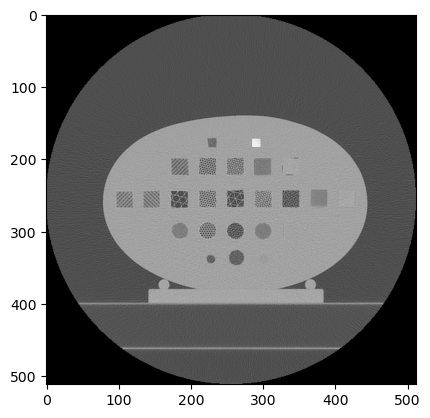

In [ ]:
# Step 1: Load the DICOM image

file_names=[]
directory = '../../RadiomiK/Immagini/RADIOMIK_TO/RAD_TO'
for filename in os.listdir(directory):
    f = os.path.join(directory, filename)
    if os.path.isfile(f) and filename.endswith('.dcm'):
        file_names.append(f)

print(len(file_names))
print(file_names[-1])
print(file_names)

dicom_image = pydicom.dcmread(file_names[-1])  

# Step 2: Extract relevant image information

pixel_array = dicom_image.pixel_array
print(pixel_array.shape)

slice_select = 38

pixelarray_slice=pixel_array[slice_select,:,:]   #FINCHE' LA SLICE THICKNESS è LA STESSA, DOVREBBE RIMANERE UGUALE (-1 rispetto a quella di imagej)
#Print max and min values of the pixel array
print(np.max(pixel_array))
print(np.min(pixel_array))

spacing = dicom_image.PixelSpacing
print(spacing)
z_dim = dicom_image.NumberOfFrames
print(z_dim)
# retrive the slice thickness, assuming all slices are the same
slice_thickness = dicom_image.SliceThickness
print(slice_thickness)

plt.imshow(pixelarray_slice, cmap='gray')
plt.show()



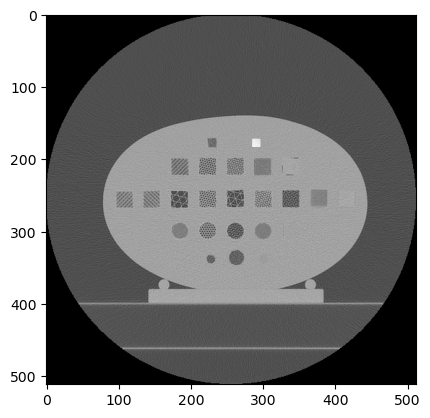

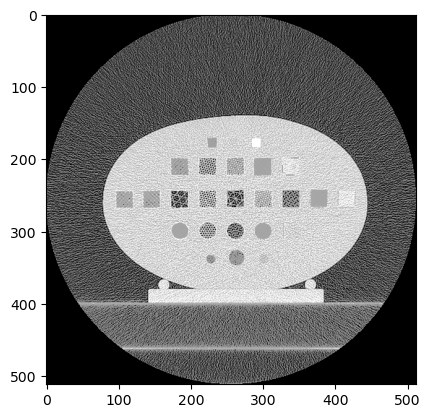

In [29]:
#Equalize the  2D image histogram
# Setting the medium value to the mean of the image and the windows width to 3 times the standard deviation

display_min = np.mean(pixelarray_slice) - 3*np.std(pixelarray_slice)
display_max = np.mean(pixelarray_slice) + 3*np.std(pixelarray_slice)

# Clip the image values to the display range
dicom_image_clipped = np.clip(pixelarray_slice, display_min, display_max)

plt.imshow(dicom_image_clipped, cmap='gray')
plt.show()

# Normalize the clipped image to the [0, 1] range
dicom_image_normalized = (dicom_image_clipped - display_min) / (display_max - display_min)
dicom_image_equalized = exposure.equalize_hist(dicom_image_normalized)

# Display the normalized image using 'gray' colormap
plt.imshow(dicom_image_equalized, cmap='gray')
plt.show()

In [30]:
#ROI definitions
#posizioni del TOSHIBA
#Cylindrical ROI

center_y = [185, 223, 261, 300]  
center_x = [300, 300, 300, 300]
center_x =np.array(center_x)
center_y =np.array(center_y)

center_z = slice_select  
radius = 8   #da verificare
height = 5   #da verificare

#Rectangular ROI
center_x_rect_TO = [185, 223, 262, 300, 339, 109, 146, 185, 223, 262, 300, 339, 378, 416, 339] 
center_y_rect_TO = [211, 211, 211, 211, 211, 256, 256, 256, 256, 256, 256, 255, 255, 255, 300] 
center_x_rect_TO =np.array(center_x_rect_TO)
center_y_rect_TO =np.array(center_y_rect_TO)

width = 8

'''
#Test1
center_x=center_x + 1 
center_x_rect_TO=center_x_rect_TO + 1


#Test2
center_x=center_x -1
center_x_rect_TO=center_x_rect_TO - 1

#Test3
center_y=center_y + 1
center_y_rect_TO=center_y_rect_TO + 1

#Test4
center_y=center_y - 1
center_y_rect_TO=center_y_rect_TO - 1

#Test5
center_z=center_z + 1

#Test6
center_z=center_z - 1

#Test7
center_x=center_x + 1
center_x_rect_TO=center_x_rect_TO + 1
center_z=center_z + 1

#Test8
center_x=center_x - 1
center_x_rect_TO=center_x_rect_TO - 1
center_z=center_z - 1
'''

#Test9
center_y_t=center_y + 1
center_y_rect_TO_t=center_y_rect_TO + 1
center_z_t=center_z + 1
'''
#Test10
center_y_t=center_y - 1
center_y_rect_TO_t=center_y_rect_TO - 1
center_z_t=center_z - 1
'''

# Create a binary mask for cylindrical ROI
maschere=[]

for k, j in zip(center_x, center_y):
    print(k)
    print(j)
    mask3D = np.zeros_like(dicom_image.pixel_array).astype('uint16')

    for i in range (mask3D.shape[0]):
        if i >= center_z - height and i <= center_z + height:
            x, y = np.ogrid[:pixelarray_slice.shape[0], :pixelarray_slice.shape[1]]
            mask3D[i,:,:][np.sqrt((x - k)**2 + (y - j)**2) <= radius] = 1
    print(mask3D.shape)
    maschere.append(mask3D)
        
mask3D_cyl0 = maschere[0]
mask3D_cyl1 = maschere[1]
mask3D_cyl2 = maschere[2]
mask3D_cyl3 = maschere[3]

# Create a binary mask for rectangular ROI
maschere_rect=[]

for k, j in zip(center_x_rect_TO, center_y_rect_TO):
    print(k)
    print(j)
    mask3D_rect = np.zeros_like(dicom_image.pixel_array).astype('uint16')

    for i in range (mask3D_rect.shape[0]):
        if i >= center_z - height and i <= center_z + height:
            mask3D_rect[i,:,:][j-width:j+width, k-width:k+width] = 1
    print(mask3D_rect.shape)
    maschere_rect.append(mask3D_rect)

mask3D_rect0 = maschere_rect[0]
mask3D_rect1 = maschere_rect[1]
mask3D_rect2 = maschere_rect[2]
mask3D_rect3 = maschere_rect[3]
mask3D_rect4 = maschere_rect[4]
mask3D_rect5 = maschere_rect[5]
mask3D_rect6 = maschere_rect[6]
mask3D_rect7 = maschere_rect[7]
mask3D_rect8 = maschere_rect[8]
mask3D_rect9 = maschere_rect[9]
mask3D_rect10 = maschere_rect[10]
mask3D_rect11 = maschere_rect[11]
mask3D_rect12 = maschere_rect[12]
mask3D_rect13 = maschere_rect[13]
mask3D_rect14 = maschere_rect[14]



300
185
(79, 512, 512)
300
223
(79, 512, 512)
300
261
(79, 512, 512)
300
300
(79, 512, 512)
185
211
(79, 512, 512)
223
211
(79, 512, 512)
262
211
(79, 512, 512)
300
211
(79, 512, 512)
339
211
(79, 512, 512)
109
256
(79, 512, 512)
146
256
(79, 512, 512)
185
256
(79, 512, 512)
223
256
(79, 512, 512)
262
256
(79, 512, 512)
300
256
(79, 512, 512)
339
255
(79, 512, 512)
378
255
(79, 512, 512)
416
255
(79, 512, 512)
339
300
(79, 512, 512)


In [31]:
# Create a binary mask for cylindrical ROI test
maschere=[]

for k, j in zip(center_x, center_y_t):
    print(k)
    print(j)
    mask3D = np.zeros_like(dicom_image.pixel_array).astype('uint16')

    for i in range (mask3D.shape[0]):
        if i >= center_z_t - height and i <= center_z_t + height:
            x, y = np.ogrid[:pixelarray_slice.shape[0], :pixelarray_slice.shape[1]]
            mask3D[i,:,:][np.sqrt((x - k)**2 + (y - j)**2) <= radius] = 1
    print(mask3D.shape)
    maschere.append(mask3D)
        
mask3D_cyl0_t = maschere[0]
mask3D_cyl1_t = maschere[1]
mask3D_cyl2_t = maschere[2]
mask3D_cyl3_t = maschere[3]

# Create a binary mask for rectangular ROI
maschere_rect=[]

for k, j in zip(center_x_rect_TO, center_y_rect_TO_t):
    print(k)
    print(j)
    mask3D_rect = np.zeros_like(dicom_image.pixel_array).astype('uint16')

    for i in range (mask3D_rect.shape[0]):
        if i >= center_z_t - height and i <= center_z_t + height:
            mask3D_rect[i,:,:][j-width:j+width, k-width:k+width] = 1
    print(mask3D_rect.shape)
    maschere_rect.append(mask3D_rect)

mask3D_rect0_t = maschere_rect[0]
mask3D_rect1_t = maschere_rect[1]
mask3D_rect2_t = maschere_rect[2]
mask3D_rect3_t = maschere_rect[3]
mask3D_rect4_t = maschere_rect[4]
mask3D_rect5_t = maschere_rect[5]
mask3D_rect6_t = maschere_rect[6]
mask3D_rect7_t = maschere_rect[7]
mask3D_rect8_t = maschere_rect[8]
mask3D_rect9_t = maschere_rect[9]
mask3D_rect10_t = maschere_rect[10]
mask3D_rect11_t = maschere_rect[11]
mask3D_rect12_t = maschere_rect[12]
mask3D_rect13_t = maschere_rect[13]
mask3D_rect14_t = maschere_rect[14]

300
186
(79, 512, 512)
300
224
(79, 512, 512)
300
262
(79, 512, 512)
300
301
(79, 512, 512)
185
212
(79, 512, 512)
223
212
(79, 512, 512)
262
212
(79, 512, 512)
300
212
(79, 512, 512)
339
212
(79, 512, 512)
109
257
(79, 512, 512)
146
257
(79, 512, 512)
185
257
(79, 512, 512)
223
257
(79, 512, 512)
262
257
(79, 512, 512)
300
257
(79, 512, 512)
339
256
(79, 512, 512)
378
256
(79, 512, 512)
416
256
(79, 512, 512)
339
301
(79, 512, 512)


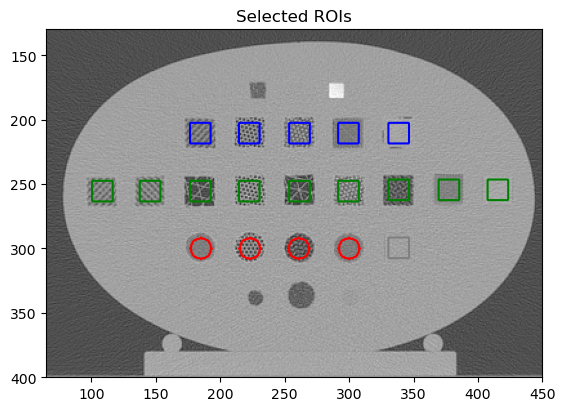

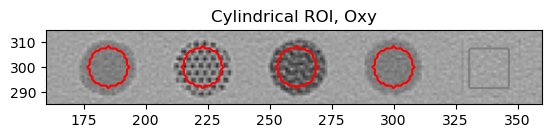

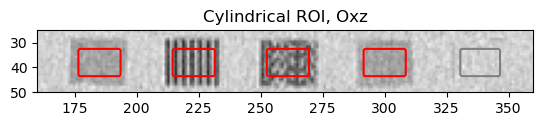

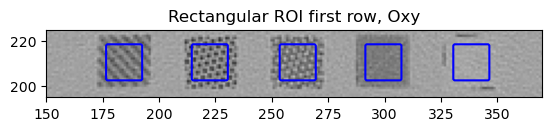

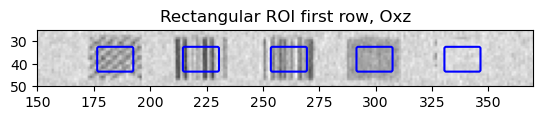

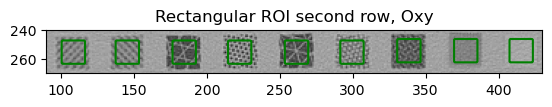

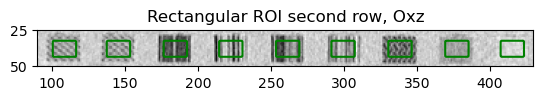

In [35]:
#plot the contours of the ROIs on the image
plt.imshow(pixelarray_slice, cmap='gray')
plt.contour(mask3D_cyl0[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_cyl1[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_cyl2[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_cyl3[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_rect0[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect1[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect2[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect3[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect4[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect5[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect6[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect7[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect8[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect9[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect10[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect11[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect12[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect13[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect14[slice_select,:,:], [0.5], colors='gray')

'''
plt.contour(mask3D_cyl0_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_cyl1_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_cyl2_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_cyl3_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect0_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect1_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect2_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect3_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect4_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect5_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect6_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect7_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect8_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect9_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect10_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect11_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect12_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect13_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect14_t[slice_select,:,:], [0.5], colors='y')
'''
plt.title('Selected ROIs')
plt.xlim(65, 450)
plt.ylim(400, 130)
plt.show()



#plot the zoomed contours of the cylindrical ROI on the image
plt.imshow(pixelarray_slice, cmap='gray')
plt.contour(mask3D_cyl0[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_cyl1[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_cyl2[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_cyl3[slice_select,:,:], [0.5], colors='r')
plt.contour(mask3D_rect14[slice_select,:,:], [0.5], colors='gray')
'''
plt.contour(mask3D_cyl0_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_cyl1_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_cyl2_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_cyl3_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect14_t[slice_select,:,:], [0.5], colors='y')
'''
plt.xlim(160, 360)
plt.ylim(285, 315)
plt.title('Cylindrical ROI, Oxy')
plt.show()

#plot the contours of the cylindrical ROI on the image on the z axis
plt.imshow(pixel_array[:, 300, :], cmap='gray')
plt.contour(mask3D_cyl0[:,300,:], [0.5], colors='r')
plt.contour(mask3D_cyl1[:,300,:], [0.5], colors='r')
plt.contour(mask3D_cyl2[:,300,:], [0.5], colors='r')
plt.contour(mask3D_cyl3[:,300,:], [0.5], colors='r')
plt.contour(mask3D_rect14[:,300,:], [0.5], colors='gray')
'''
plt.contour(mask3D_cyl0_t[:,300,:], [0.5], colors='y')
plt.contour(mask3D_cyl1_t[:,300,:], [0.5], colors='y')
plt.contour(mask3D_cyl2_t[:,300,:], [0.5], colors='y')
plt.contour(mask3D_cyl3_t[:,300,:], [0.5], colors='y')
plt.contour(mask3D_rect14_t[:,300,:], [0.5], colors='y')
'''
plt.title('Cylindrical ROI, Oxz')
plt.xlim(160, 360)
plt.ylim(50, 25)
plt.show()

#plot the zoomed contours of the rectangular ROI on the image
plt.imshow(pixelarray_slice, cmap='gray')
plt.contour(mask3D_rect0[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect1[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect2[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect3[slice_select,:,:], [0.5], colors='b')
plt.contour(mask3D_rect4[slice_select,:,:], [0.5], colors='b')
'''
plt.contour(mask3D_rect0_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect1_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect2_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect3_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect4_t[slice_select,:,:], [0.5], colors='y')
'''
plt.xlim(150, 370)
plt.ylim(195, 225)
plt.title('Rectangular ROI first row, Oxy')
plt.show()

#plot the contours of the rectangular ROI on the image on the z axis
plt.imshow(pixel_array[:, 211, :], cmap='gray')
plt.contour(mask3D_rect0[:,211,:], [0.5], colors='b')
plt.contour(mask3D_rect1[:,211,:], [0.5], colors='b')
plt.contour(mask3D_rect2[:,211,:], [0.5], colors='b')
plt.contour(mask3D_rect3[:,211,:], [0.5], colors='b')
plt.contour(mask3D_rect4[:,211,:], [0.5], colors='b')
'''
plt.contour(mask3D_rect0_t[:,211,:], [0.5], colors='y')
plt.contour(mask3D_rect1_t[:,211,:], [0.5], colors='y')
plt.contour(mask3D_rect2_t[:,211,:], [0.5], colors='y')
plt.contour(mask3D_rect3_t[:,211,:], [0.5], colors='y')
plt.contour(mask3D_rect4_t[:,211,:], [0.5], colors='y')
'''
plt.title('Rectangular ROI first row, Oxz')
plt.xlim(150, 370)
plt.ylim(50, 25)
plt.show()

#plot the zoomed contours of the rectangular ROI on the image
plt.imshow(pixelarray_slice, cmap='gray')
plt.contour(mask3D_rect5[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect6[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect7[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect8[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect9[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect10[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect11[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect12[slice_select,:,:], [0.5], colors='g')
plt.contour(mask3D_rect13[slice_select,:,:], [0.5], colors='g')
'''
plt.contour(mask3D_rect5_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect6_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect7_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect8_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect9_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect10_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect11_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect12_t[slice_select,:,:], [0.5], colors='y')
plt.contour(mask3D_rect13_t[slice_select,:,:], [0.5], colors='y')
'''
plt.xlim(90, 430)
plt.ylim(270, 240)
plt.title('Rectangular ROI second row, Oxy')
plt.show()

#plot the contours of the rectangular ROI on the image on the z axis
plt.imshow(pixel_array[:, 256, :], cmap='gray')
plt.contour(mask3D_rect5[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect6[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect7[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect8[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect9[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect10[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect11[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect12[:,256,:], [0.5], colors='g')
plt.contour(mask3D_rect13[:,256,:], [0.5], colors='g')
'''
plt.contour(mask3D_rect5_t[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect6_t[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect7_t[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect8_t[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect9_t[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect10_t[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect11_t[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect12_t[:,256,:], [0.5], colors='y')
plt.contour(mask3D_rect13_t[:,256,:], [0.5], colors='y')
'''
plt.title('Rectangular ROI second row, Oxz')
plt.xlim(90, 430)
plt.ylim(50, 25)
plt.show()



In [33]:
def create_dicom_from_array(mask, output_path, path):
    # Create a new DICOM dataset
    ds = FileDataset(output_path, {}, file_meta=dicom_image.file_meta, preamble=b'\0' * 128)
    ds.SOPClassUID = '1.2.840.10008.5.1.4.1.1.66' # DICOM SEG   #'1.2.840.10008.5.1.4.1.1.2'  # CT Image Storage
    ds.SOPInstanceUID = generate_uid()
    ds.file_meta = pydicom.Dataset()
    ds.FrameOfReferenceUID = dicom_image.FrameOfReferenceUID  
    ds.ImagePositionPatient = dicom_image.ImagePositionPatient
    ds.ImageOrientationPatient = dicom_image.ImageOrientationPatient

    # Set necessary metadata
    ds.PatientName = 'Anonymous'
    ds.PatientID = dicom_image.PatientID
    ds.Rows = mask.shape[1]
    ds.Columns = mask.shape[2]
    ds.PixelSpacing = dicom_image.PixelSpacing  # Define pixel spacing
    ds.SliceThickness = dicom_image.SliceThickness  # Define slice thickness
    ds.NumberOfFrames = mask.shape[0]
    ds.SamplesPerPixel = dicom_image.SamplesPerPixel # Set Samples Per Pixel
    ds.PhotometricInterpretation = 'MONOCHROME2'  # Set Photometric Interpretation
    ds.BitsAllocated = 16
    ds.BitsStored = 16
    ds.HighBit = 15
    ds.PixelRepresentation = 1  # Unsigned integer
    if hasattr(dicom_image, 'RotationDirection'):
        ds.RotationDirection = dicom_image.RotationDirection
    ds.PositionReferenceIndicator = dicom_image.PositionReferenceIndicator
    if hasattr(dicom_image, 'SliceLocation'):
        ds.SliceLocation = dicom_image.SliceLocation
    if hasattr(dicom_image, 'PatientPosition'):
        ds.PatientPosition = dicom_image.PatientPosition

    # Set pixel data
    ds.PixelData = mask.tobytes()
    
    ds.file_meta.TransferSyntaxUID = pydicom.uid.ImplicitVRLittleEndian
    # Save the DICOM file
    ds.save_as(path+output_path)

In [ ]:
# Usage
maschere = [mask3D_cyl0, mask3D_cyl1, mask3D_cyl2, mask3D_cyl3, mask3D_rect0, mask3D_rect1, mask3D_rect2, mask3D_rect3, mask3D_rect4, mask3D_rect5, mask3D_rect6, mask3D_rect7, mask3D_rect8, mask3D_rect9, mask3D_rect10, mask3D_rect11, mask3D_rect12, mask3D_rect13, mask3D_rect14] 
output_path = ['mask_cyl0_TO.dcm', 'mask_cyl1_TO.dcm', 'mask_cyl2_TO.dcm', 'mask_cyl3_TO.dcm', 'mask_rect0_TO.dcm', 'mask_rect1_TO.dcm', 'mask_rect2_TO.dcm', 'mask_rect3_TO.dcm', 'mask_rect4_TO.dcm', 'mask_rect5_TO.dcm', 'mask_rect6_TO.dcm', 'mask_rect7_TO.dcm', 'mask_rect8_TO.dcm', 'mask_rect9_TO.dcm', 'mask_rect10_TO.dcm', 'mask_rect11_TO.dcm', 'mask_rect12_TO.dcm', 'mask_rect13_TO.dcm', 'mask_rect14_TO.dcm']
path = '../../RadiomiK/Immagini/RADIOMIK_TO/RAD_TO_mask_test/Test4/'  # Output path for the DICOM file

for mask_name, output in zip (maschere, output_path):
    
    create_dicom_from_array(mask_name, output, path)